# <font color="blue">Пространственное распределение региональных статистических данных по территории субъекта РФ на сетке 1×1 км</font> 
---

Установка необходимых библиотек (запустить один раз)

In [1]:
#!pip install quackosm
#!pip install geopandas pyogrio

Импорт библиотек

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point
import pandas as pd
import numpy as np
import json
import joblib
from matplotlib.colors import LogNorm
from map_parsing import *
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix

import warnings

warnings.filterwarnings("ignore")

%load_ext jupyter_black

### <font color="green">Загрузка данных, создание сетки и сохранение результатов</font> 

In [3]:
name = input("Введите samara_oblast или jewish_autonomous_oblast: ")

if name not in ["samara_oblast", "jewish_autonomous_oblast"]:
    raise ValueError(
        f"Некорректный ввод: '{name}'. Допустимые значения: samara_oblast, jewish_autonomous_oblast"
    )

path_geojson = f"sources/{name}.geojson"
path_pbf = f"sources/{name}.pbf"

print(f"\n✅ Выбран субъект: {name}")
print(f"Граница: {path_geojson}")
print(f"OSM: {path_pbf}")

Введите samara_oblast или jewish_autonomous_oblast:  jewish_autonomous_oblast



✅ Выбран субъект: jewish_autonomous_oblast
Граница: sources/jewish_autonomous_oblast.geojson
OSM: sources/jewish_autonomous_oblast.pbf


In [4]:
# Загружаем границу и все слои OSM
boundary, layers, all_layers = read_map(path_geojson, path_pbf)

Можно вывести информацио о загруженных слоях
```python
print("\nДоступные слои:", list(all_layers.keys()))
print(f"Точек: {len(all_layers.get('points', [])):,}")
print(f"Линий: {len(all_layers.get('lines', [])):,}")
print(f"Полигонов: {len(all_layers.get('multipolygons', [])):,}")

In [5]:
# Создаём сетку ячеек 1×1 км внутри границы
grid_gdf, cell_w, cell_h = create_grid_within_boundary(boundary, cell_size_km=1)

# Агрегируем все слои OSM в сетку (подсчитываем объекты по ячейкам)
final_stats = aggregate_all_layers_to_grid(all_layers, grid_gdf, boundary)

# Создаём текстовые описания для каждой ячейки
descriptions = final_stats.apply(
    lambda row: create_cell_description(row, all_layers), axis=1
)
final_stats["types_json"] = descriptions.apply(lambda x: x[1])  # JSON

# Добавляем координаты центров ячеек (для визуализации)
if "geometry" in final_stats.columns:
    final_stats["center_lon"] = final_stats["geometry"].apply(
        lambda geom: geom.centroid.x
    )
    final_stats["center_lat"] = final_stats["geometry"].apply(
        lambda geom: geom.centroid.y
    )

# Считаем общее количество объектов в каждой ячейке (сумма по всем слоям)
count_cols = [f"count_{layer}" for layer in all_layers.keys()]
final_stats["total_objects"] = final_stats[count_cols].sum(axis=1)

Размер ячейки: 1 км
Сетка в bounding box: 332 × 209 = 69388 ячеек
Ячеек внутри границы: 38306

Итоговая таблица: 38306 ячеек
Колонки: ['cell_id', 'count_points', 'types_points', 'count_lines', 'types_lines', 'count_multilinestrings', 'types_multilinestrings', 'count_multipolygons', 'types_multipolygons', 'count_other_relations', 'types_other_relations', 'cell_x', 'cell_y', 'geometry']


### <font color="green">Извлечение информации для ячеек</font> 

In [6]:
# DataFrame для работы
df_main = final_stats.drop(columns=["geometry"]).copy()
df_main["types_json"] = df_main["types_json"].apply(safe_json_parse)

In [7]:
def extract_buildings_count(types_json):
    """
    Извлекает количество зданий из JSON-описания ячейки.
    Ищет все объекты, в названии типа которых есть "building".
    """
    if isinstance(types_json, dict):
        total = 0
        for layer_data in types_json.get("layers", {}).values():
            for obj_type, count in layer_data.get("types", {}).items():
                if "building" in obj_type:
                    total += count
        return total
    return 0


def extract_total_objects(types_json):
    """
    Извлекает общее количество всех объектов из JSON-описания ячейки.
    Суммирует все типы объектов без фильтрации.
    """
    if isinstance(types_json, dict):
        total = 0
        for layer_data in types_json.get("layers", {}).values():
            total += sum(layer_data.get("types", {}).values())
        return total
    return 0

In [8]:
# Добавляем в df_main колонки с количеством зданий и общим количеством объектов
df_main["total_buildings"] = df_main["types_json"].apply(extract_buildings_count)
df_main["total_objects"] = df_main["types_json"].apply(extract_total_objects)

In [9]:
# Выводим статистику
print(f"✅ Загружено: {len(df_main)} ячеек")
print(f"  Ячеек с зданиями: {(df_main['total_buildings'] > 0).sum():,}")
print(f"  Всего зданий: {df_main['total_buildings'].sum():,}")

✅ Загружено: 38306 ячеек
  Ячеек с зданиями: 806
  Всего зданий: 31,744


### <font color="green">Частотный анализ с весами (редкие объекты = больший вес)</font> 

In [10]:
# Собираем статистику по всем типам объектов
type_frequency = {}
type_total_count = {}

for idx, row in df_main.iterrows():
    types_json = row["types_json"]
    if isinstance(types_json, dict):
        for layer_data in types_json.get("layers", {}).values():
            for obj_type, count in layer_data.get("types", {}).items():
                type_frequency[obj_type] = type_frequency.get(obj_type, 0) + 1
                type_total_count[obj_type] = type_total_count.get(obj_type, 0) + count

total_cells = len(df_main)
print(f"Всего типов объектов: {len(type_frequency)}")

Всего типов объектов: 204


In [11]:
# Расчёт весов: чем реже объект, тем выше вес
type_weights = {}
for obj_type in type_frequency:
    frequency = type_frequency[obj_type] / total_cells
    inverse_frequency = 1.0 / (frequency + 0.01)
    type_weights[obj_type] = inverse_frequency

total_weight_sum = sum(type_weights.values())
for obj_type in type_weights:
    type_weights[obj_type] /= total_weight_sum

sorted_weights = sorted(type_weights.items(), key=lambda x: x[1], reverse=True)

print(f"\nТоп 20 типов объектов")
for i, (obj_type, weight) in enumerate(sorted_weights[:20], 1):
    freq = type_frequency[obj_type]
    total = type_total_count[obj_type]
    print(
        f"  {i:2}. {obj_type[:45]:45s}: вес={weight:.6f} (в {freq} ячейках, всего {total} шт)"
    )


# Расчёт веса каждой ячейки
def calculate_cell_weight(types_json):
    if not isinstance(types_json, dict):
        return 0
    total = 0
    for layer_data in types_json.get("layers", {}).values():
        for obj_type, count in layer_data.get("types", {}).items():
            weight = type_weights.get(obj_type, 0)
            total += weight * np.log1p(count)
    return total


df_main["cell_weight"] = df_main["types_json"].apply(calculate_cell_weight)


Топ 20 типов объектов
   1. barrier:hedge                                : вес=0.005224 (в 1 ячейках, всего 2 шт)
   2. highway:motorway_junction                    : вес=0.005224 (в 1 ячейках, всего 2 шт)
   3. building:silo                                : вес=0.005224 (в 1 ячейках, всего 2 шт)
   4. landuse:reservoir                            : вес=0.005224 (в 1 ячейках, всего 1 шт)
   5. man_made:water_works                         : вес=0.005224 (в 1 ячейках, всего 2 шт)
   6. amenity:prison                               : вес=0.005224 (в 1 ячейках, всего 1 шт)
   7. building:farm_auxiliary                      : вес=0.005224 (в 1 ячейках, всего 2 шт)
   8. building:grandstand                          : вес=0.005224 (в 1 ячейках, всего 5 шт)
   9. building:miyes                               : вес=0.005224 (в 1 ячейках, всего 1 шт)
  10. building:bungalow                            : вес=0.005224 (в 1 ячейках, всего 1 шт)
  11. building:yes;civic                           : вес=

In [12]:
# Пустые ячейки получают минимальный ненулевой вес, основанный на распределении
# Находим минимальный вес среди непустых ячеек
non_zero_weights = df_main[df_main["cell_weight"] > 0]["cell_weight"]
if len(non_zero_weights) > 0:
    min_non_zero = non_zero_weights.min()
    # Базовый вес для пустых = 20% от минимального веса непустой ячейки
    base_weight = min_non_zero * 0.2
else:
    base_weight = 0.001  # если вдруг нет непустых

print(f"\nВес для пустых ячеек")
print(
    f"Минимальный вес непустой ячейки: {min_non_zero:.8f}"
    if len(non_zero_weights) > 0
    else "  Нет непустых ячеек"
)
print(f"Вес для пустых: {base_weight:.8f}")

# Применяем базовый вес ко всем ячейкам
df_main["cell_weight_with_base"] = df_main["cell_weight"].copy()
# Пустые ячейки (cell_weight == 0) получают базовый вес
mask_empty = df_main["cell_weight"] == 0
df_main.loc[mask_empty, "cell_weight_with_base"] = base_weight

# Добавляем небольшой базовый вес ко всем ячейкам (для сглаживания)
smoothing = base_weight * 0.1
df_main["cell_weight_with_base"] = df_main["cell_weight_with_base"] + smoothing

print(f"Коэффициент сглаживания: {smoothing:.8f}")


Вес для пустых ячеек
Минимальный вес непустой ячейки: 0.00074051
Вес для пустых: 0.00014810
Коэффициент сглаживания: 0.00001481


In [13]:
# Нормализация коэффициентов (сумма = 1)
total_weight = df_main["cell_weight_with_base"].sum()
df_main["coefficient_freq"] = df_main["cell_weight_with_base"] / total_weight

print(f"\nКоэффициенты рассчитаны")
print(f"Всего ячеек: {len(df_main):,}")
print(f"Пустых ячеек с базовым весом: {mask_empty.sum():,}")
print(f"Сумма коэффициентов: {df_main['coefficient_freq'].sum():.6f}")


Коэффициенты рассчитаны
Всего ячеек: 38,306
Пустых ячеек с базовым весом: 34,066
Сумма коэффициентов: 1.000000


In [14]:
# Статистика по базовому весу
empty_coeff = (
    df_main[mask_empty]["coefficient_freq"].iloc[0] if mask_empty.sum() > 0 else 0
)
empty_share = mask_empty.sum() * empty_coeff

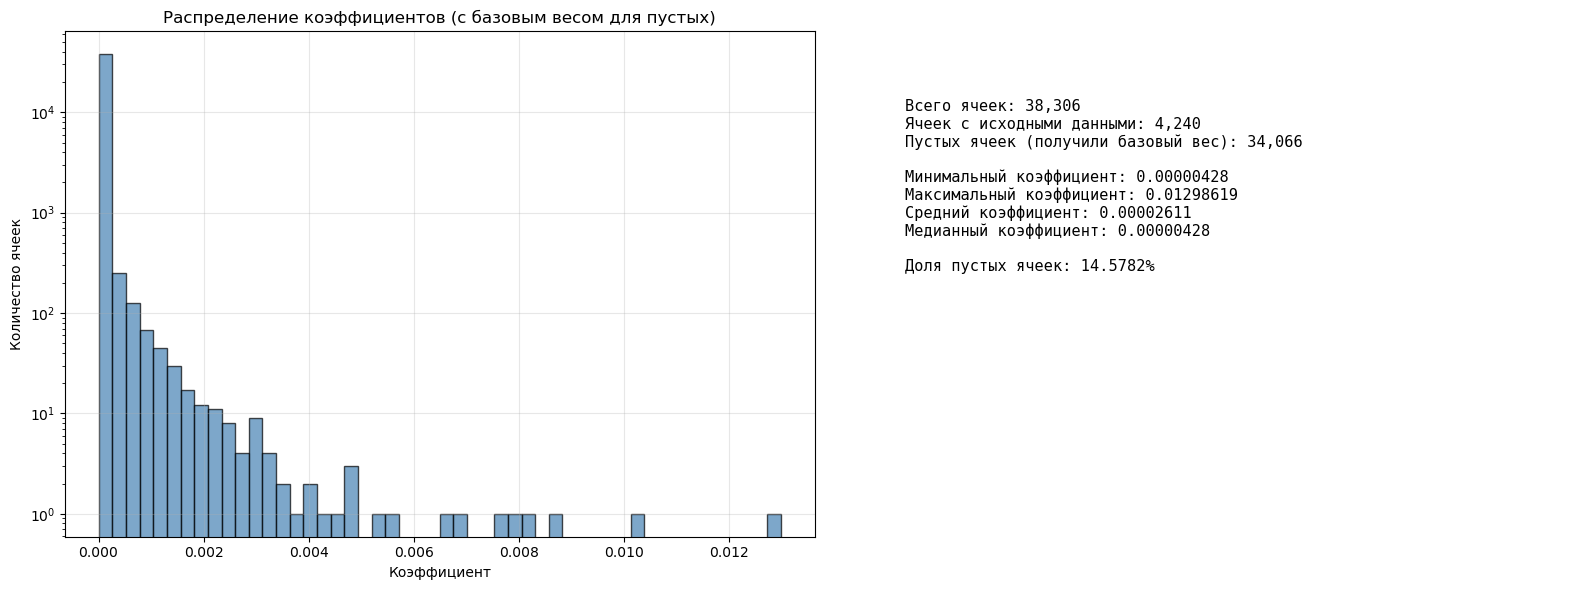

  Добавлена колонка: coefficient_freq
  Сумма коэффициентов: 1.00


In [15]:
# Визуализация распределения коэффициентов
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
all_coeffs = df_main["coefficient_freq"]
ax1.hist(all_coeffs, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
ax1.set_xlabel("Коэффициент")
ax1.set_ylabel("Количество ячеек")
ax1.set_title("Распределение коэффициентов (с базовым весом для пустых)")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.axis("off")
stats_text = f"""
Всего ячеек: {len(df_main):,}
Ячеек с исходными данными: {(df_main['cell_weight'] > 0).sum():,}
Пустых ячеек (получили базовый вес): {mask_empty.sum():,}

Минимальный коэффициент: {all_coeffs.min():.8f}
Максимальный коэффициент: {all_coeffs.max():.8f}
Средний коэффициент: {all_coeffs.mean():.8f}
Медианный коэффициент: {all_coeffs.median():.8f}

Доля пустых ячеек: {empty_share:.4%}
"""
ax2.text(
    0.1,
    0.9,
    stats_text,
    transform=ax2.transAxes,
    fontsize=11,
    verticalalignment="top",
    fontfamily="monospace",
)

plt.tight_layout()
plt.show()

# Добавление в основную таблицу
df_main["coefficient_freq"] = (
    df_main["cell_id"]
    .map(dict(zip(df_main["cell_id"], df_main["coefficient_freq"])))
    .fillna(0)
)

print(f"  Добавлена колонка: coefficient_freq")
print(f"  Сумма коэффициентов: {df_main['coefficient_freq'].sum():.2f}")

### <font color="green">Расчёт пространственных весов (влияние соседей)</font> 

In [16]:
def calculate_spatial_weights(df, weight_col, radius_km=2):
    """
    Для каждой ячейки усредняет веса всех соседей в радиусе (включая себя)
    """
    coords = df[["center_lon", "center_lat"]].values
    weights = df[weight_col].values

    radius_deg = radius_km / 111.0
    tree = cKDTree(coords)

    spatial_weights = []

    for i in range(len(df)):
        indices = tree.query_ball_point(coords[i], r=radius_deg)
        # Усредняем, а не суммируем
        total = np.mean([weights[j] for j in indices])
        spatial_weights.append(total)

    spatial_weights = np.array(spatial_weights)
    coefficient_spatial = spatial_weights / spatial_weights.sum()

    return coefficient_spatial


print("Расчет пространственных весов")

spatial_weights = calculate_spatial_weights(df_main, weight_col="coefficient_freq")

df_main["coefficient_spatial"] = spatial_weights

print(f"\nСтатистика пространственных весов:")
print(f"Средний вес: {df_main['coefficient_spatial'].mean():.6f}")
print(f"Максимальный вес: {df_main['coefficient_spatial'].max():.6f}")
print(f"Сумма коэффициентов: {df_main['coefficient_spatial'].sum():.6f}")

df_main["coefficient_spatial"] = (
    df_main["cell_id"]
    .map(dict(zip(df_main["cell_id"], df_main["coefficient_spatial"])))
    .fillna(0)
)

Расчет пространственных весов

Статистика пространственных весов:
Средний вес: 0.000026
Максимальный вес: 0.006314
Сумма коэффициентов: 1.000000


### <font color="green">Карта частотного распределения (без учета соседних ячеек)</font>

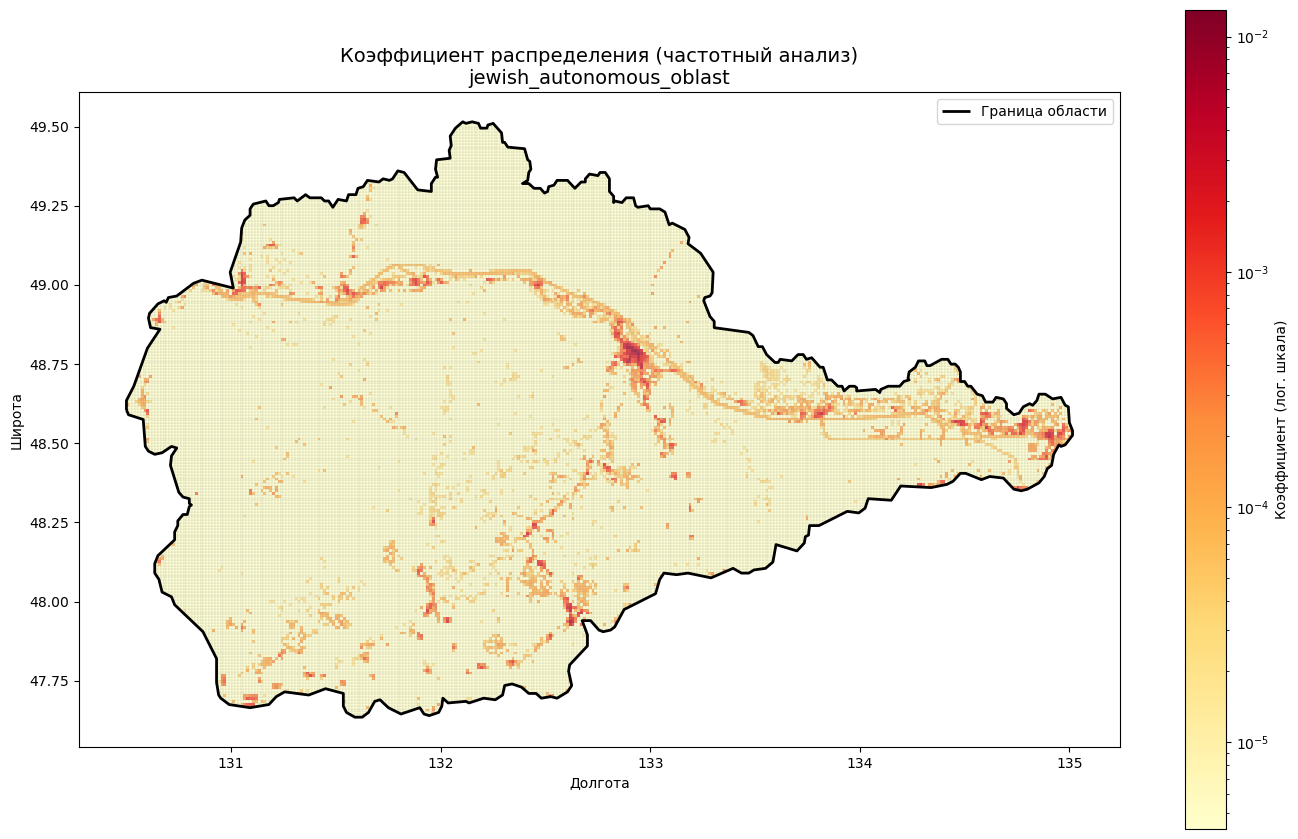

✅ Сохранено: result/jewish_autonomous_oblast.png


In [17]:
gdf_freq_coeff = grid_gdf.copy()
gdf_freq_coeff["coefficient_freq"] = (
    gdf_freq_coeff["cell_id"]
    .map(dict(zip(df_main["cell_id"], df_main["coefficient_freq"])))
    .fillna(0)
)

fig, ax = plt.subplots(1, 1, figsize=(14, 12))

gdf_freq_coeff.plot(
    column="coefficient_freq",
    ax=ax,
    cmap="YlOrRd",
    edgecolor="gray",
    linewidth=0.1,
    legend=True,
    norm=LogNorm(),
    alpha=0.8,
    legend_kwds={"label": "Коэффициент (лог. шкала)", "shrink": 0.7},
)

boundary.boundary.plot(ax=ax, color="black", linewidth=2, label="Граница области")
ax.set_title(f"Коэффициент распределения (частотный анализ)\n{name}", fontsize=14)
ax.set_xlabel("Долгота")
ax.set_ylabel("Широта")
ax.legend()

plt.tight_layout()
plt.savefig(f"result/{name}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Сохранено: result/{name}.png")

### <font color="green">Карта частотного распределения (с учетом соседних ячеек)</font>

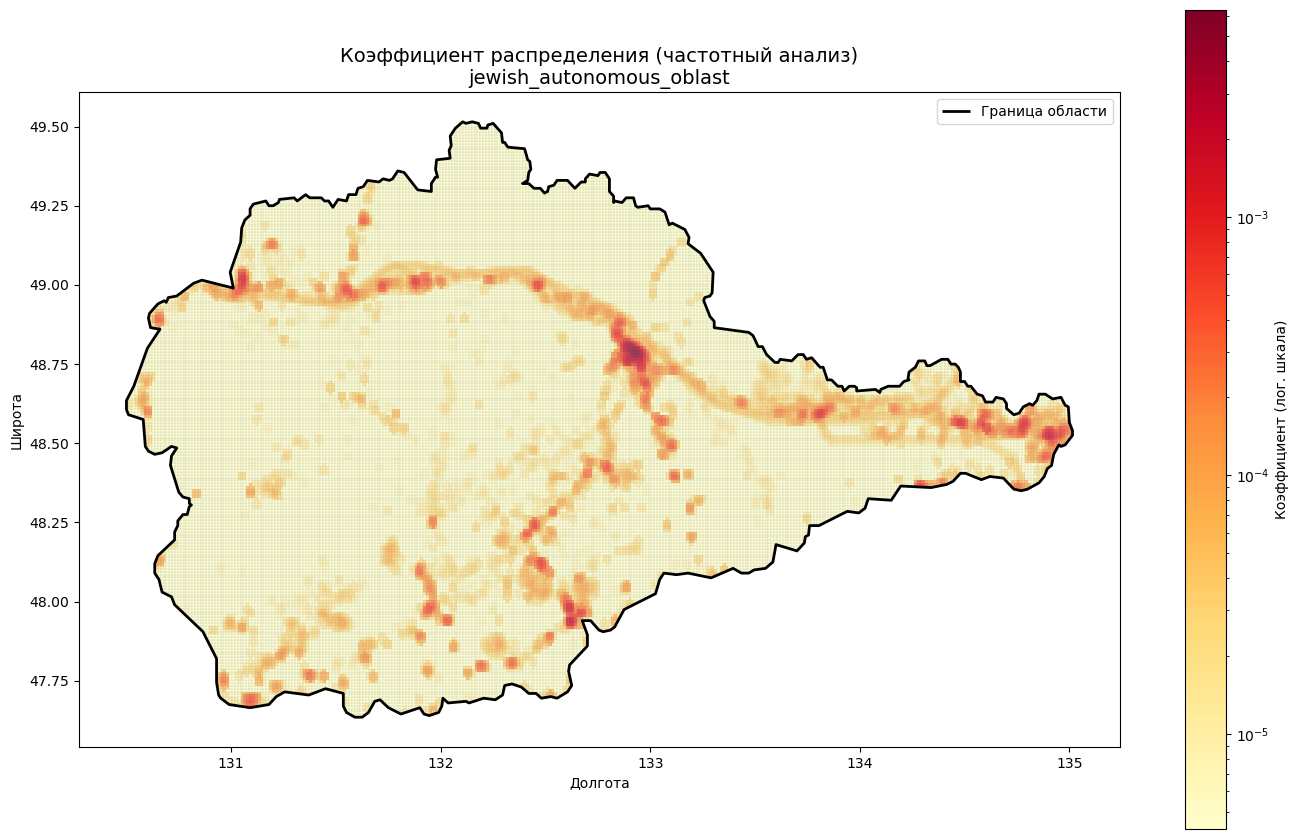

✅ Сохранено: result/jewish_autonomous_oblast_avg.png


In [18]:
gdf_freq_coeff = grid_gdf.copy()
gdf_freq_coeff["coefficient_spatial"] = (
    gdf_freq_coeff["cell_id"]
    .map(dict(zip(df_main["cell_id"], df_main["coefficient_spatial"])))
    .fillna(0)
)

fig, ax = plt.subplots(1, 1, figsize=(14, 12))

gdf_freq_coeff.plot(
    column="coefficient_spatial",
    ax=ax,
    cmap="YlOrRd",
    edgecolor="gray",
    linewidth=0.1,
    legend=True,
    norm=LogNorm(),
    alpha=0.8,
    legend_kwds={"label": "Коэффициент (лог. шкала)", "shrink": 0.7},
)

boundary.boundary.plot(ax=ax, color="black", linewidth=2, label="Граница области")
ax.set_title(f"Коэффициент распределения (частотный анализ)\n{name}", fontsize=14)
ax.set_xlabel("Долгота")
ax.set_ylabel("Широта")
ax.legend()

plt.tight_layout()
plt.savefig(f"result/{name}_avg.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Сохранено: result/{name}_avg.png")

### <font color="green">Использование линейной регрессии</font> 

In [19]:
# Загрузка обученной модели линейной регрессии
try:
    # Загрузка модели
    model_data = joblib.load("result/model.pkl")
    scaler = model_data["scaler"]
    selected_features = model_data["selected_features"]

    # Загрузка весов
    weights_df = pd.read_csv("result/weights.csv")
    feature_weights = dict(zip(weights_df["feature_name"], weights_df["weight"]))

    print(f"✅ Модель загружена. Используется {len(selected_features)} признаков.")

except FileNotFoundError:
    print(
        "❌ Файлы модели не найдены. Убедитесь, что result/model.pkl и result/weights.csv существуют."
    )
    print("Запустите сначала model_test.ipynb для обучения модели.")
    raise

# Расчет коэффициентов с использованием линейной регрессии


def calculate_ml_weight(types_json, feature_weights):
    """
    Рассчитывает вес ячейки на основе линейной регрессии
    """
    if not isinstance(types_json, dict):
        return 0

    # Извлекаем распределение типов в ячейке
    cell_type_distribution = {}
    cell_total_objects = 0

    for layer_data in types_json.get("layers", {}).values():
        for obj_type, count in layer_data.get("types", {}).items():
            cell_type_distribution[obj_type] = (
                cell_type_distribution.get(obj_type, 0) + count
            )
            cell_total_objects += count

    if cell_total_objects == 0:
        return 0

    # Преобразуем в проценты от общего числа объектов в ячейке
    cell_type_shares = {
        f"type_{k}_share": v / cell_total_objects
        for k, v in cell_type_distribution.items()
    }

    # Рассчитываем взвешенную сумму
    weight = 0
    for feature_name, share in cell_type_shares.items():
        if feature_name in feature_weights:
            weight += share * feature_weights[feature_name]

    return weight


# Применяем функцию к каждой ячейке
df_main["ml_weight"] = df_main["types_json"].apply(
    lambda x: calculate_ml_weight(x, feature_weights)
)

# Нормализация весов (сумма = 1)
min_weight = df_main["ml_weight"].min()
df_main["ml_weight_normalized"] = df_main["ml_weight"] - min_weight + 1e-10
total_ml_weight = df_main["ml_weight_normalized"].sum()

if total_ml_weight > 0:
    df_main["coefficient_ml_regression"] = (
        df_main["ml_weight_normalized"] / total_ml_weight
    )
    print("✅ Коэффициенты линейной регрессии рассчитаны")
    print(f"  Сумма коэффициентов: {df_main['coefficient_ml_regression'].sum():.6f}")
    print(
        f"  Максимальный коэффициент: {df_main['coefficient_ml_regression'].max():.8f}"
    )
    print(f"  Средний коэффициент: {df_main['coefficient_ml_regression'].mean():.8f}")
else:
    df_main["coefficient_ml_regression"] = 1.0 / len(df_main)
    print("Используется равномерное распределение")

✅ Модель загружена. Используется 50 признаков.
✅ Коэффициенты линейной регрессии рассчитаны
  Сумма коэффициентов: 1.000000
  Максимальный коэффициент: 0.02790418
  Средний коэффициент: 0.00002611


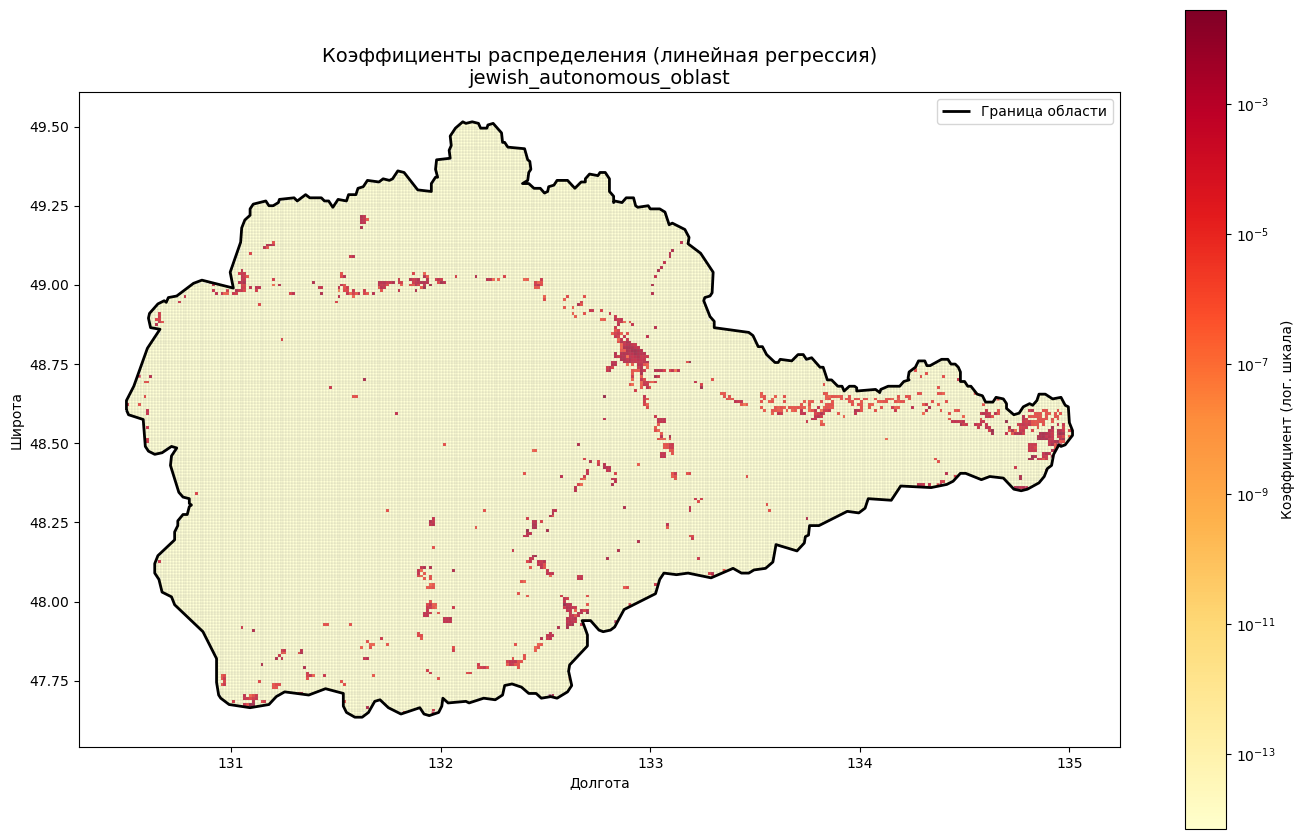

✅ Сохранено: result/jewish_autonomous_oblast_ml_regression.png


In [20]:
# Визуализация коэффициентов линейной регрессии
gdf_ml_coeff = grid_gdf.copy()
gdf_ml_coeff["coefficient_ml_regression"] = (
    gdf_ml_coeff["cell_id"]
    .map(dict(zip(df_main["cell_id"], df_main["coefficient_ml_regression"])))
    .fillna(0)
)

fig, ax = plt.subplots(1, 1, figsize=(14, 12))

gdf_ml_coeff.plot(
    column="coefficient_ml_regression",
    ax=ax,
    cmap="YlOrRd",
    edgecolor="gray",
    linewidth=0.1,
    legend=True,
    norm=LogNorm(),
    alpha=0.8,
    legend_kwds={"label": "Коэффициент (лог. шкала)", "shrink": 0.7},
)

boundary.boundary.plot(ax=ax, color="black", linewidth=2, label="Граница области")
ax.set_title(f"Коэффициенты распределения (линейная регрессия)\n{name}", fontsize=14)
ax.set_xlabel("Долгота")
ax.set_ylabel("Широта")
ax.legend()

plt.tight_layout()
plt.savefig(f"result/{name}_ml_regression.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Сохранено: result/{name}_ml_regression.png")

### <font color="green">Baseline (обычное усреднение)</font>

In [21]:
# Расчет равномерного распределения (baseline)
# Равномерное распределение: каждый пиксель получает равный вес
df_main["coefficient_uniform"] = 1.0 / len(df_main)

print(f"✅ Равномерное распределение рассчитано")
print(f"  Количество ячеек: {len(df_main):,}")
print(f"  Вес каждой ячейки: {df_main['coefficient_uniform'].iloc[0]:.8f}")
print(f"  Сумма коэффициентов: {df_main['coefficient_uniform'].sum():.6f}")

✅ Равномерное распределение рассчитано
  Количество ячеек: 38,306
  Вес каждой ячейки: 0.00002611
  Сумма коэффициентов: 1.000000


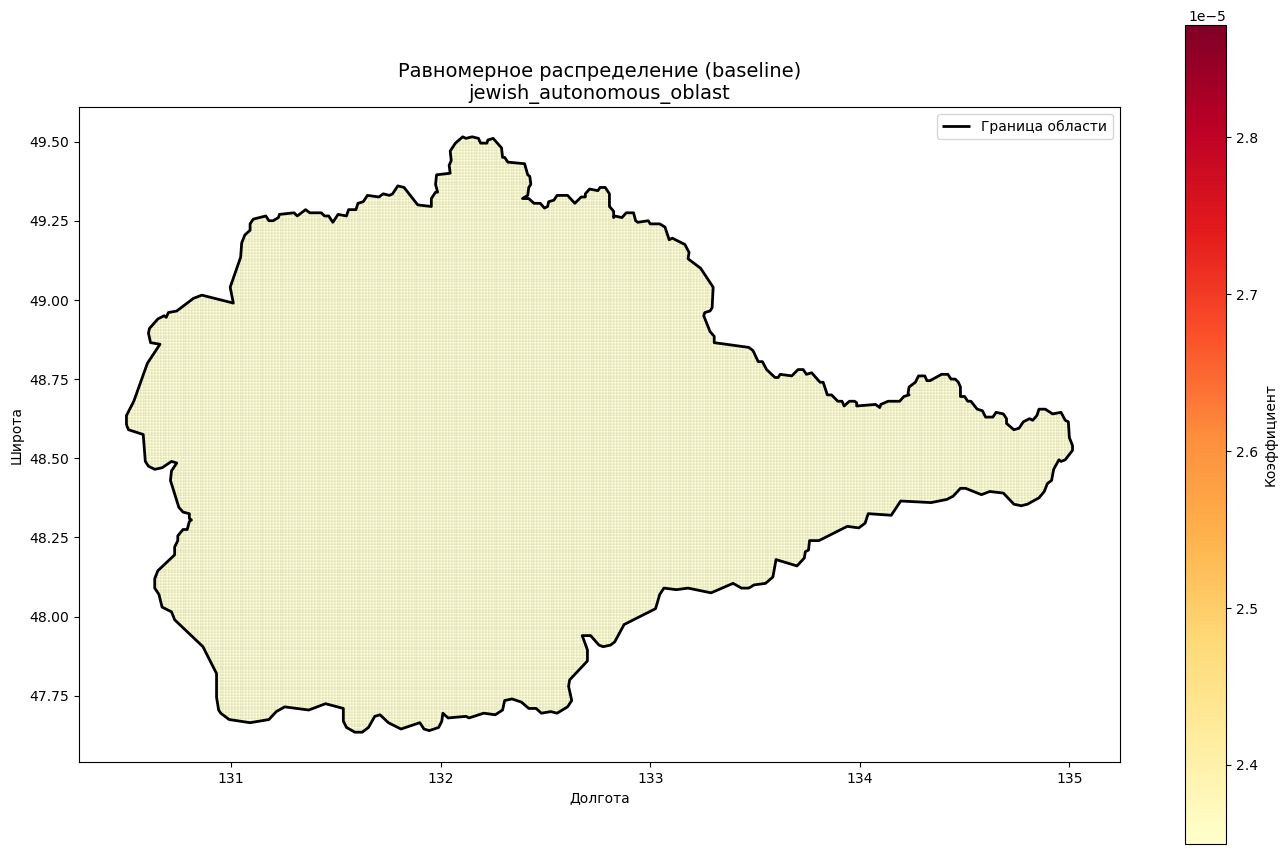

✅ Сохранено: result/jewish_autonomous_oblast_uniform.png


In [22]:
# Визуализация равномерного распределения
gdf_uniform = grid_gdf.copy()
gdf_uniform["coefficient_uniform"] = (
    gdf_uniform["cell_id"]
    .map(dict(zip(df_main["cell_id"], df_main["coefficient_uniform"])))
    .fillna(0)
)

fig, ax = plt.subplots(1, 1, figsize=(14, 12))

gdf_uniform.plot(
    column="coefficient_uniform",
    ax=ax,
    cmap="YlOrRd",
    edgecolor="gray",
    linewidth=0.1,
    legend=True,
    alpha=0.8,
    legend_kwds={"label": "Коэффициент", "shrink": 0.7},
)

boundary.boundary.plot(ax=ax, color="black", linewidth=2, label="Граница области")
ax.set_title(f"Равномерное распределение (baseline)\n{name}", fontsize=14)
ax.set_xlabel("Долгота")
ax.set_ylabel("Широта")
ax.legend()

plt.tight_layout()
plt.savefig(f"result/{name}_uniform.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Сохранено: result/{name}_uniform.png")

### <font color="green">Сравнение методов</font>

Сравнение методов распределения:


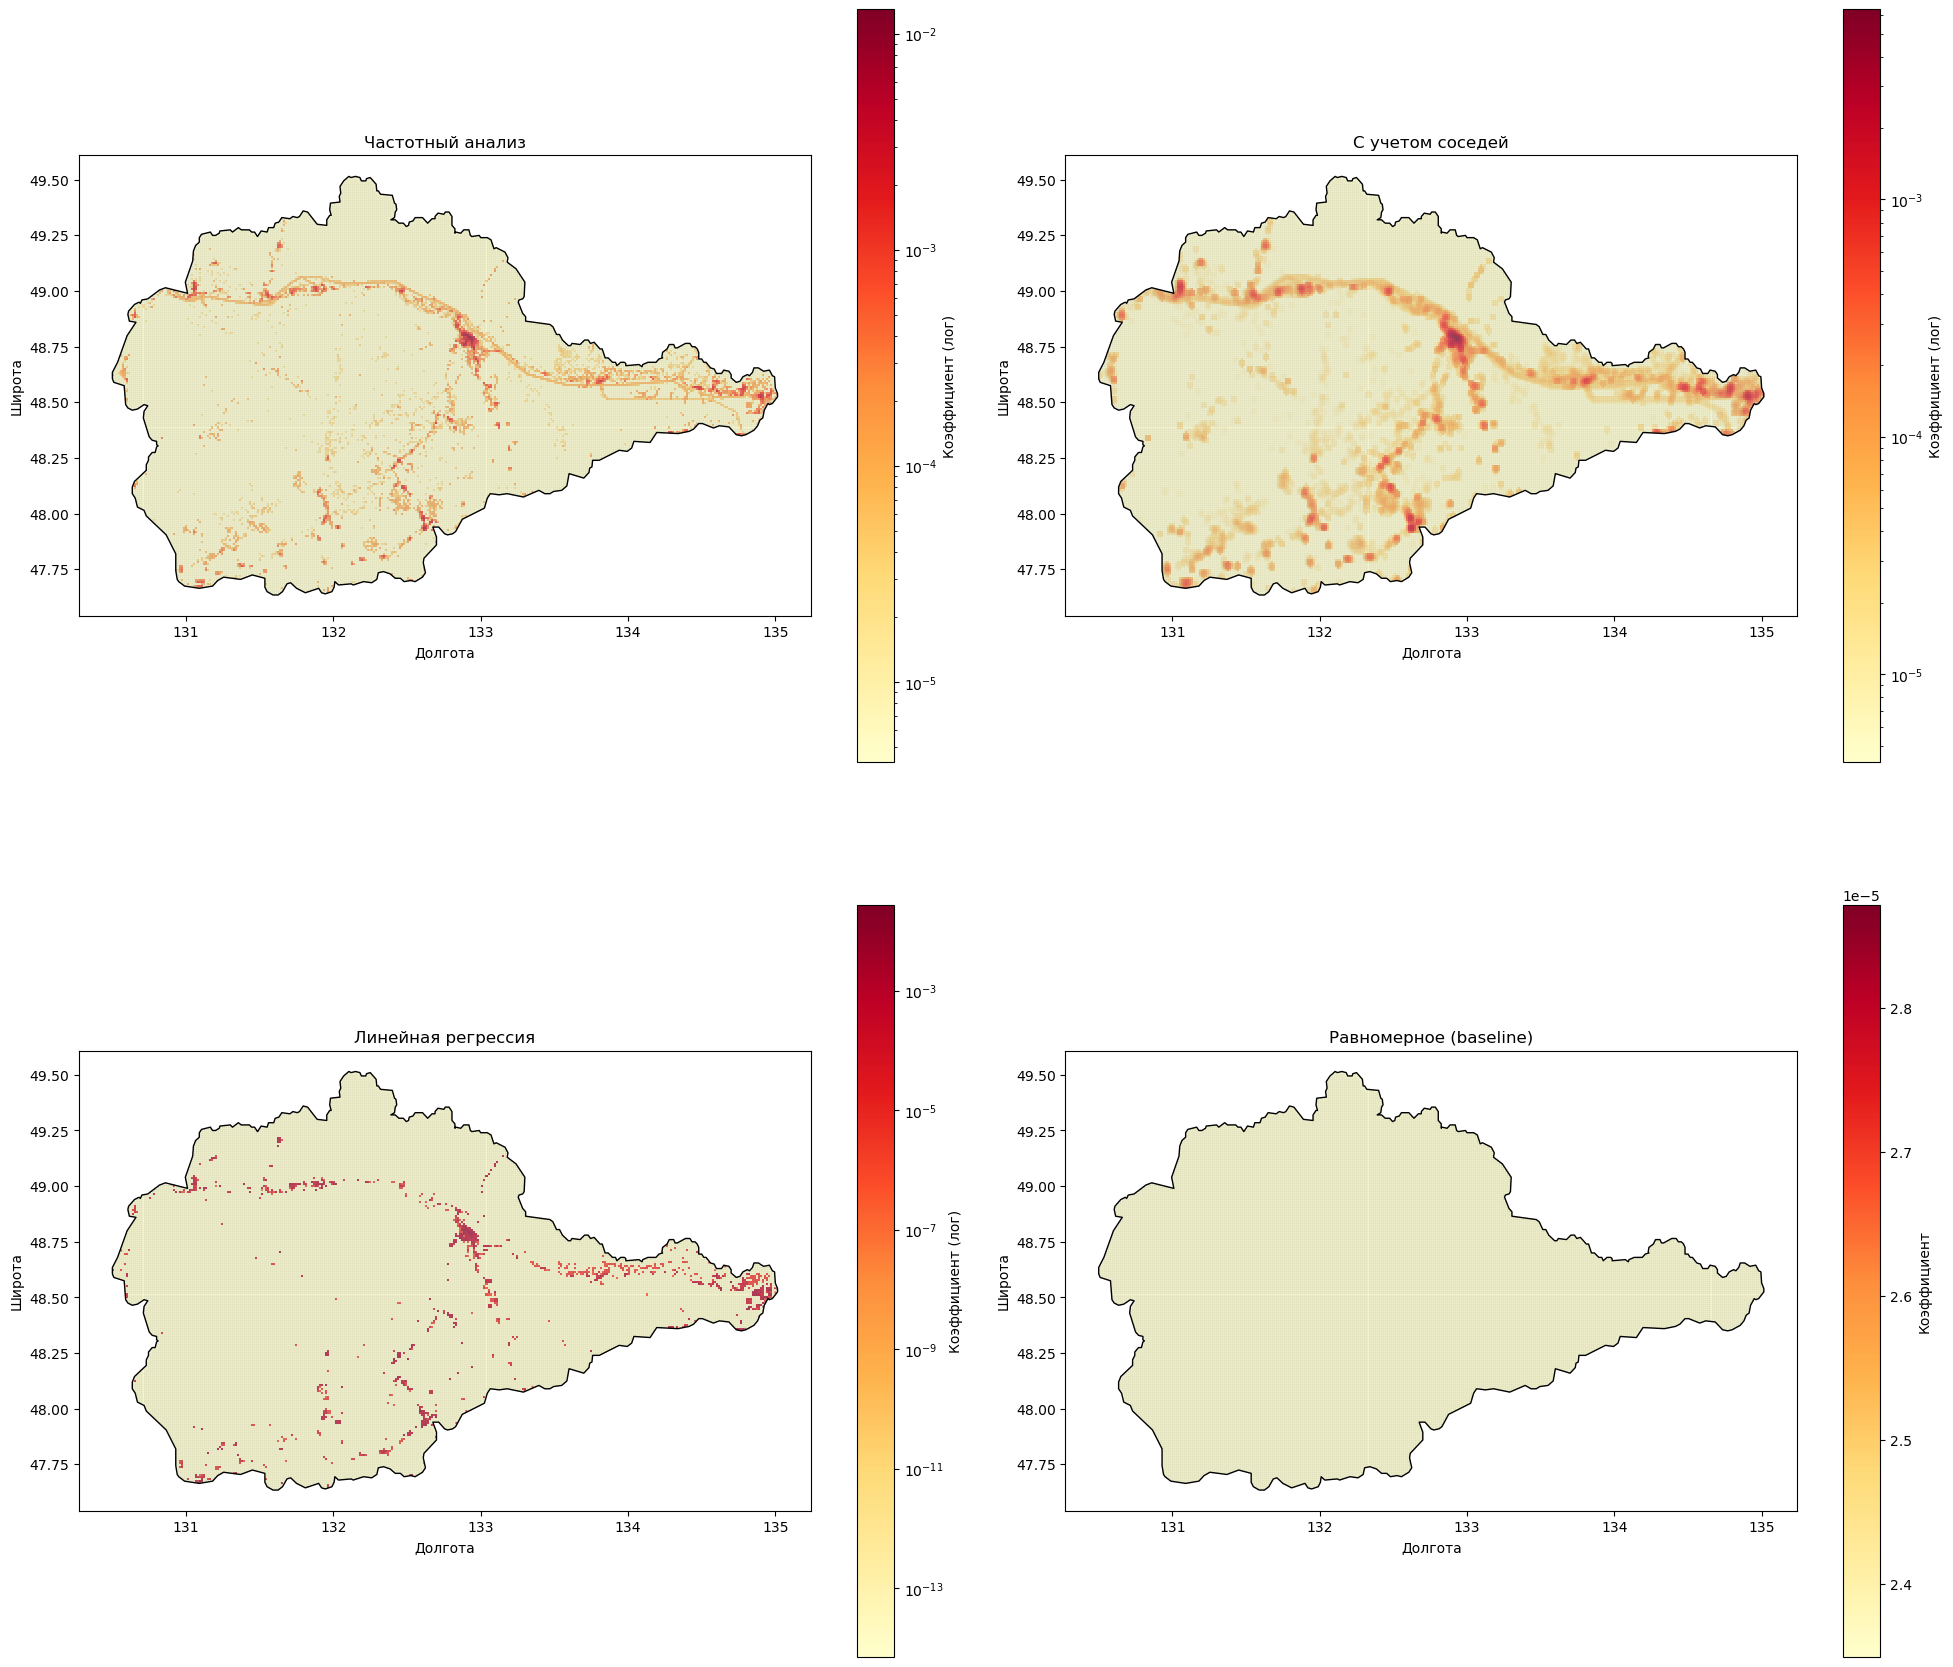

✅ Сохранено: result/jewish_autonomous_oblast_all_methods_comparison.png


In [23]:
print("Сравнение методов распределения:")

# Создаем GeoDataFrames для сравнения
methods_data = [
    ("coefficient_freq", "Частотный анализ"),
    ("coefficient_spatial", "С учетом соседей"),
    ("coefficient_ml_regression", "Линейная регрессия"),
    ("coefficient_uniform", "Равномерное (baseline)"),
]

fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes = axes.flatten()

for ax, (col, title) in zip(axes, methods_data):
    gdf = grid_gdf.copy()
    gdf["value"] = (
        gdf["cell_id"].map(dict(zip(df_main["cell_id"], df_main[col]))).fillna(0)
    )

    # Для равномерного распределения используем линейную шкалу, для остальных - логарифмическую
    if col == "coefficient_uniform":
        gdf.plot(
            column="value",
            ax=ax,
            cmap="YlOrRd",
            edgecolor="gray",
            linewidth=0.1,
            legend=True,
            alpha=0.8,
            legend_kwds={"label": "Коэффициент", "shrink": 0.7},
        )
    else:
        gdf.plot(
            column="value",
            ax=ax,
            cmap="YlOrRd",
            edgecolor="gray",
            linewidth=0.1,
            legend=True,
            norm=LogNorm(),
            alpha=0.8,
            legend_kwds={"label": "Коэффициент (лог)", "shrink": 0.7},
        )

    boundary.boundary.plot(ax=ax, color="black", linewidth=1)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Долгота")
    ax.set_ylabel("Широта")

plt.tight_layout()
plt.savefig(f"result/{name}_all_methods_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Сохранено: result/{name}_all_methods_comparison.png")

In [24]:
# Статистическое сравнение ВСЕХ методов
print("Статистическое сравнение методов:")

comparison_stats = pd.DataFrame(
    {
        "Метод": [
            "Частотный анализ",
            "С учетом соседей",
            "Линейная регрессия",
            "Равномерное (baseline)",
        ],
        "Среднее": [
            df_main["coefficient_freq"].mean(),
            df_main["coefficient_spatial"].mean(),
            df_main["coefficient_ml_regression"].mean(),
            df_main["coefficient_uniform"].mean(),
        ],
        "Медиана": [
            df_main["coefficient_freq"].median(),
            df_main["coefficient_spatial"].median(),
            df_main["coefficient_ml_regression"].median(),
            df_main["coefficient_uniform"].median(),
        ],
        "Стандартное отклонение": [
            df_main["coefficient_freq"].std(),
            df_main["coefficient_spatial"].std(),
            df_main["coefficient_ml_regression"].std(),
            df_main["coefficient_uniform"].std(),
        ],
        "Минимум": [
            df_main["coefficient_freq"].min(),
            df_main["coefficient_spatial"].min(),
            df_main["coefficient_ml_regression"].min(),
            df_main["coefficient_uniform"].min(),
        ],
        "Максимум": [
            df_main["coefficient_freq"].max(),
            df_main["coefficient_spatial"].max(),
            df_main["coefficient_ml_regression"].max(),
            df_main["coefficient_uniform"].max(),
        ],
    }
)

display(comparison_stats)

# Коэффициенты вариации (для оценки дифференциации)
print(f"\nКоэффициенты вариации (чем выше - тем больше дифференциация):")
for method, col in [
    ("Частотный", "coefficient_freq"),
    ("Соседи", "coefficient_spatial"),
    ("Регрессия", "coefficient_ml_regression"),
    ("Равномерное", "coefficient_uniform"),
]:
    cv = df_main[col].std() / df_main[col].mean()
    print(f"  {method}: {cv:.4f}")

Статистическое сравнение методов:


,Метод,Среднее,Медиана,Стандартное отклонение,Минимум,Максимум
0,Частотный анализ,0.000026,4.279394e-06,1.970812e-04,4.279394e-06,0.012986
1,С учетом соседей,0.000026,4.279003e-06,1.410997e-04,4.279003e-06,0.006314
2,Линейная регрессия,0.000026,7.081860e-15,4.165807e-04,7.081860e-15,0.027904
3,Равномерное (baseline),0.000026,2.610557e-05,1.549752e-17,2.610557e-05,0.000026



Коэффициенты вариации (чем выше - тем больше дифференциация):
  Частотный: 7.5494
  Соседи: 5.4050
  Регрессия: 15.9575
  Равномерное: 0.0000


### <font color="green">Сохранение данных</font>

In [25]:
df_main[
    [
        "cell_id",
        "cell_x",
        "cell_y",
        "types_json",
        "center_lon",
        "center_lat",
        "coefficient_freq",  # Частотный анализ
        "coefficient_spatial",  # С учетом соседей
        "coefficient_ml_regression",  # Линейная регрессия
        "coefficient_uniform",
    ]
].to_csv(f"result/{name}.csv", index=False, encoding="utf-8")

print(f"✅ Все коэффициенты сохранены в result/{name}.csv")

✅ Все коэффициенты сохранены в result/jewish_autonomous_oblast.csv


### <font color="green">Пример использования (расчет показателя)</font>

Ниже представлен код, демонстрирующий, как распределить показатель между ячейками 1×1 км на основе коэффициента `coefficient_freq`.

```python
regional_ratio = 10_000_000
df_main["allocated_ratio"] = regional_ratio * df_main["coefficient_freq"]

print("Распределение показателя")
print(f"Показатель: {regional_ratio:,.0f} руб.")
print(f"Сумма распределения: {df_main['allocated_ratio'].sum():,.0f} руб.")